# Lezione 5.1: Fondamenti di Scikit-Learn con Bike Sharing

In questo notebook esploreremo i concetti fondamentali di **Scikit-Learn** applicandoli al nostro caso di studio reale: il dataset **European Bike Sharing**.

## Obiettivi
1.  Caricare e preparare i dati (Preprocessing).
2.  Capire la struttura `X` (Features) e `y` (Target).
3.  Utilizzare l'API Estimator per addestrare un modello di Regressione Lineare.
4.  Valutare il modello con metriche di base (MAE, RMSE).

## Step 1
accedi a Pgadmin ed utilizzano il query editor, posizionati sul dtwh bikesharing già creato e scrivi una query per trovare:
data_completa
mese
giorno_settimana
is_weekend
total_rental
avg_duration

## Step 2
scarica il risultato in un cvs e posizionalo nella stessa directory di questo Notebook

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Caricamento dei Dati


leggi i dati dal CSV.

In [15]:
# Caricamento dati da CSV (estratti dal DWH)
df = pd.read_csv("bike_daily.csv")

# Parsing data
df['data_completa'] = pd.to_datetime(df['data_completa'])

df.head()


,data_completa,mese,giorno_settimana,is_weekend,total_rentals,avg_duration
0,2022-08-26,8,5,False,3,15.333333
1,2022-08-27,8,6,True,3,25.333333
2,2022-08-28,8,7,True,3,28.333333
3,2022-08-29,8,1,False,7,53.428571
4,2022-08-30,8,2,False,3,19.333333


In [16]:
# Ordiniamo i dati per data (fondamentale per lag e rolling)
df = df.sort_values("data_completa").reset_index(drop=True)

# shift() e rolling() funzionano solo se i dati sono in ordine di tempo
# senza questo → feature sbagliate

In [ ]:
# Feature: valore del giorno precedente
df['lag_1'] = df['total_rentals'].shift(1)
# Significato  “Quanti noleggi ci sono stati ieri?”
# Perché è potente:  se ieri erano alti → oggi probabilmente simili  
# introduce dipendenza temporale

# .shift(1)
#     È un metodo di pandas che “sposta” la colonna in basso di 1 riga.
#     Significa: per il giorno di oggi, metti nella nuova colonna il valore di ieri.

In [ ]:
# Feature: media mobile degli ultimi 7 giorni,   la media dei noleggi degli ultimi 7 giorni
df['rolling_7'] = df['total_rentals'].rolling(window=7).mean()

# .rolling(window=7)  Questo metodo crea una finestra mobile (window)
#       Parte da ogni riga e guarda indietro (di default)  
#       “Per ogni riga, prendo quella riga + le 6 precedenti.”
#     Parametro: window = 7
#     Significa: Per ogni riga guarda gli ultimi 7 valori.
#     È come dire: “Per oggi, guarda la settimana appena passata.”

# lag_1:  Guarda solo ieri   Molto preciso ma rumoroso

# rolling_7:  Guarda una settimana   Più stabile, meno rumore

In [ ]:
# Rimuoviamo le righe iniziali con valori mancanti
df = df.dropna().reset_index(drop=True)
# shift(1) crea NaN nella prima riga
# rolling(7) crea NaN nelle prime 6
# scikit-learn non accetta NaN

# df.dropna(subset=['lag_1','rolling_7'], inplace=True)


In [20]:
import numpy as np

# Trasformazione ciclica del mese
# Stagionalità ciclica del mese (seno e coseno)
df['mese_sin'] = np.sin(2 * np.pi * df['mese'] / 12)
df['mese_cos'] = np.cos(2 * np.pi * df['mese'] / 12)
# Significato permette al modello di capire che:
# gennaio e dicembre sono “vicini”
# introduce stagionalità annuale
# Schema: mese → (sin, cos) → ciclo continuo


In [ ]:
# Trasformazione ciclica del mese
df['mese_sin'] = np.sin(2 * np.pi * df['mese'] / 12)  # un numero tra -1 e 1.
df['mese_cos'] = np.cos(2 * np.pi * df['mese'] / 12)

# | Mese | Sin | Cos   |
# | ---- | --- | ----- |
# | 2    | 0.5 | 0.86  |
# | 4    | 0.5 | -0.86 |
# coordinate complete (x, y)

In [21]:
# =========================
# 6) Definizione X (features) e y (target)
# =========================

features = [
    "giorno_settimana",
    "is_weekend",
    "lag_1",
    "rolling_7",
    "mese_sin",
    "mese_cos"
]

X = df[features]            # tabella input
y = df["total_rentals"]     # valore da predire

print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (188, 6)
Shape di y: (188,)


In [22]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 150
Test samples: 38


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))

# Dopo l’addestramento il modello ha imparato:
#     model.coef_ → i pesi (w1, w2, w3)
#     model.intercept_ → l’intercetta (b)
# zip() è una funzione Python che accoppia elementi di due liste posizione per posizione.

Intercetta: -0.06480980664806246
Coefficienti: {'giorno_settimana': np.float64(-0.17586836570016337), 'is_weekend': np.float64(0.18302887687548272), 'lag_1': np.float64(-0.08627000902088258), 'rolling_7': np.float64(1.2259936943662173), 'mese_sin': np.float64(0.3402746971708125), 'mese_cos': np.float64(0.2467296434774209)}


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 2.8779503425125452
RMSE: 3.4376963623135657


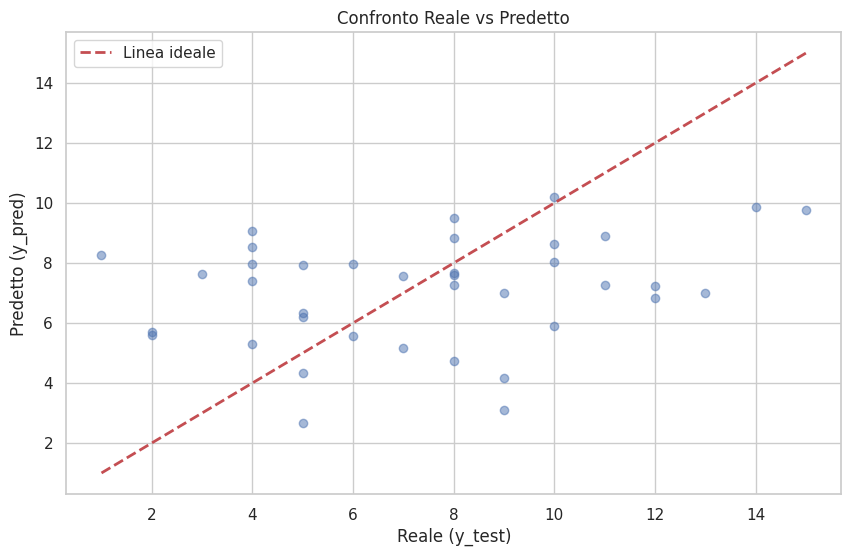

In [25]:
import matplotlib.pyplot as plt

# Creiamo la figura
plt.figure(figsize=(10, 6))

# Scatter: valori reali vs valori predetti
plt.scatter(y_test, y_pred, alpha=0.5)

# Linea ideale y = x (usiamo i limiti del test)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    lw=2,
    label='Linea ideale'
)

# Etichette e titolo
plt.xlabel('Reale (y_test)')
plt.ylabel('Predetto (y_pred)')
plt.title('Confronto Reale vs Predetto')

# Legenda
plt.legend()

# Mostra il grafico
plt.show()


## 2. Definizione di X e y

Nel Machine Learning supervisionato, dobbiamo separare:
*   **X (Features)**: Le variabili che usiamo per fare la previsione.
*   **y (Target)**: La variabile che vogliamo prevedere.

**Obiettivo**: Prevedere il numero totale di noleggi (`total_rentals`) basandoci sulle caratteristiche temporali.

In [3]:
# Selezioniamo le feature
features = ['mese', 'giorno_settimana', 'is_weekend']
target = 'total_rentals'

X = df[features]
y = df[target]

# verifichiamo la dimensione di X ed Y
print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (194, 3)
Shape di y: (194,)


## 3. Train-Test Split

Non dobbiamo mai valutare il modello sugli stessi dati usati per l'addestramento. Usiamo `train_test_split`.

In [4]:
from sklearn.model_selection import train_test_split

# Dividiamo: 80% Training, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 155
Test samples: 39


## 4. Addestramento del Modello (Estimator API)

Useremo una **Regressione Lineare**. In Scikit-Learn, il flusso è sempre:
1.  Importare la classe.
2.  Istanziare l'oggetto (configurare iperparametri).
3.  Chiamare `.fit()` sui dati di training.

In [5]:
# 1. Importiamo la classe che utilizzeremo
from sklearn.linear_model import LinearRegression

# 1. Istanziazione
model = LinearRegression()

# 2. Fitting (Apprendimento)
model.fit(X_train, y_train)

# Vediamo cosa ha imparato (i coefficienti)
print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))

Intercetta: 5.76564953140277
Coefficienti: {'mese': np.float64(-0.03404668690078005), 'giorno_settimana': np.float64(-0.07242766455772963), 'is_weekend': np.float64(-0.22442450008002668)}


## 5. Previsione e Valutazione

Ora usiamo `.predict()` sui dati di test (che il modello non ha mai visto) e confrontiamo le previsioni con la realtà.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Generiamo previsioni
y_pred = model.predict(X_test)

# Calcoliamo l'errore
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE (Errore Medio Assoluto): {mae:.2f}")
print(f"RMSE (Radice Errore Quadratico Medio): {rmse:.2f}")

MAE (Errore Medio Assoluto): 2.70
RMSE (Radice Errore Quadratico Medio): 3.46


In [7]:
df['total_rentals'].describe()


count    194.000000
mean       5.154639
std        3.326266
min        1.000000
25%        2.250000
50%        5.000000
75%        7.000000
max       15.000000
Name: total_rentals, dtype: float64

## 6. Visualizzazione dei Risultati

Un grafico vale più di mille numeri. Vediamo quanto le previsioni si avvicinano alla realtà.

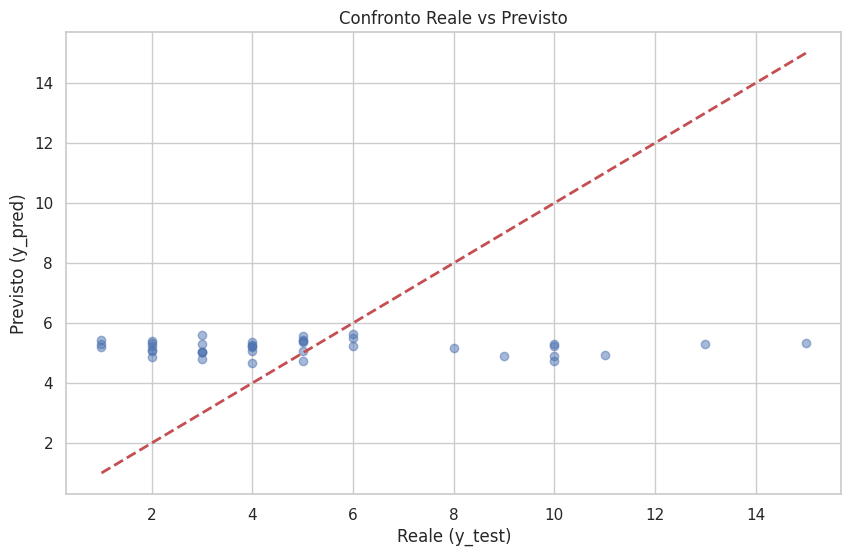

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linea ideale
plt.xlabel('Reale (y_test)')
plt.ylabel('Previsto (y_pred)')
plt.title('Confronto Reale vs Previsto')
plt.show()